# 🎮 Classificação Indicativa de Jogos Eletrônicos no Brasil
## Projeto Final — Introdução à Ciência de Dados

**Fonte dos dados:** Ministério da Justiça e Segurança Pública — Classificação Indicativa de Jogos Eletrônicos
[Portal de Dados Abertos](https://dados.mj.gov.br/dataset/5138a6ca-8009-4ffb-b95a-052f76d62a33/resource/4e892aac-aeb3-4e39-a398-3b2565a7320c/download/jogoeletronico202511141500.xlsx)

---

### Pergunta orientadora
> **Existe uma correlação entre o ano de produção e a diversidade/intensidade dos descritores de conteúdo (violência, conteúdo sexual, drogas) nos jogos registrados?**

### Perguntas derivadas
1. **(P1)** A diversidade e a intensidade dos descritores de conteúdo mudam ao longo das décadas?
2. **(P2)** Qual é a distribuição das classificações etárias (Livre, 10, 12, 14, 16, 18) no acervo?
3. **(P3)** Quais plataformas aparecem com maior frequência? Há mudança das plataformas dominantes ao longo do tempo?
4. **(P4)** Qual o percentual de concordância entre a classificação **pretendida** pelos distribuidores e a **atribuída** pelo órgão? Nas divergências, o órgão é mais rígido ou mais flexível?
###Contexto técnico
No sistema brasileiro de Classificação Indicativa (a ClassInd, do Ministério da Justiça), todo produto recebe duas coisas diferentes:
A faixa etária (Livre, 10, 12, 14, 16, 18) diz a partir de que idade o conteúdo é recomendado. Já os descritores de conteúdo dizem o porquê daquela faixa — ou seja, quais tipos de conteúdo sensível foram encontrados na obra e justificaram a classificação. O Guia Prático de Classificação Indicativa detalha os critérios usados para atribuir tanto a faixa etária quanto os descritores de conteúdo a um produto. Por isso aparecem juntos: o símbolo mostra a idade, e ao lado vêm rótulos curtos como "violência", "conteúdo sexual", "drogas", "linguagem imprópria".
Os descritores se organizam em grandes eixos temáticos. Historicamente, os critérios da Classificação Indicativa se sustentam em três grandes temas — sexo, violência e drogas — considerados inadequados à formação de crianças e adolescentes, analisados pela frequência, contexto e intensidade com que aparecem na obra. Vale registrar que isso mudou recentemente: em 2025 o Ministério ampliou os descritores para incluir a interatividade, passando a considerar quatro eixos — sexo e nudez, violência, drogas e interatividade.


## 1. Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import collections

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.max_columns", None)

print("pandas", pd.__version__)

pandas 2.2.2


## 2. Carregamento dos dados

O notebook tenta baixar o arquivo direto do Portal de Dados Abertos. Se o link estiver
indisponível, ele pede o upload manual do arquivo `jogoeletronico202511141500.xlsx`
(que está no repositório como reserva).

In [2]:
URL = "https://dados.mj.gov.br/dataset/5138a6ca-8009-4ffb-b95a-052f76d62a33/resource/4e892aac-aeb3-4e39-a398-3b2565a7320c/download/jogoeletronico202511141500.xlsx"
ARQ = "jogoeletronico202511141500.xlsx"

df = None
# 1ª tentativa: baixar direto da URL
try:
    df = pd.read_excel(URL)
    print("✅ Dados carregados diretamente da URL do Portal de Dados Abertos.")
except Exception as e:
    print("⚠️ Não foi possível baixar da URL:", repr(e)[:120])
    # 2ª tentativa: arquivo já presente no diretório (repositório/Colab)
    try:
        df = pd.read_excel(ARQ)
        print("✅ Dados carregados do arquivo local de reserva.")
    except Exception as e2:
        # 3ª tentativa: upload manual (Google Colab)
        try:
            from google.colab import files
            print("⬆️ Faça o upload do arquivo de reserva:", ARQ)
            up = files.upload()
            df = pd.read_excel(list(up.keys())[0])
            print("✅ Dados carregados do upload.")
        except Exception as e3:
            raise RuntimeError("Não foi possível carregar os dados por nenhum método.")

print("Dimensões:", df.shape)

✅ Dados carregados diretamente da URL do Portal de Dados Abertos.
Dimensões: (9496, 18)


## 3. Entendimento e descrição do conjunto

Cada linha é **um pedido de classificação indicativa** de um jogo eletrônico analisado pelo
Ministério da Justiça. Principais colunas:

| Coluna | Significado | Tipo |
|---|---|---|
| `Título no Brasil` / `Título Original` | Nome do jogo | texto |
| `Ano de Produção` | Ano de produção do jogo | numérica (veio como texto) |
| `Distribuidor` / `Produtor / Criador` | Empresa que pediu / criou o jogo | categórica/texto |
| `Classificação Pretendida` | Faixa etária **sugerida pelo distribuidor** | categórica ordinal |
| `Classificação Atribuída` | Faixa etária **homologada pelo órgão** | categórica ordinal |
| `Descritores de conteúdo` | Conteúdos sensíveis (violência, drogas, sexual...) separados por vírgula | texto (multivalorado) |
| `Plataformas` | Plataformas do jogo, separadas por vírgula | texto (multivalorado) |
| `Data assinatura`, `Data DOU`, `Data Cadastro` | Datas do processo administrativo | data (texto) |
| `Nº documento`, `Nº Protocolo`, `Seção 1, Página` | Identificadores do processo | texto |
| `Natureza da Análise`, `Tipo de Classificação`, `Elementos Interativos` | Metadados do processo | categórica |


In [3]:
df.head()

,Título no Brasil,Título Original,Ano de Produção,Distribuidor,Classificação Pretendida,Classificação Atribuída,Descritores de conteúdo,Plataformas,Data assinatura,Nº documento,Data DOU,"Seção 1, Página",Natureza da Análise,Tipo de Classificação,Produtor / Criador,Elementos Interativos,Nº Protocolo,Data Cadastro
0,Brothers A Tale of Two Sons (A.K.A Brothers: ...,Brothers A Tale of Two Sons (A.K.A Brothers: ...,2013,Positivo Informática S/A.,Não recomendado para menores de 12 (doze) anos,Livre,violência,"Computador (PC), Playstation 3, Playstation 4,...",05/07/2013,127,08/07/2013,26,Análise comum,Análise prévia,505 GAMES,Não se aplica,08017.004162/2013-72,2013-04-30 00:00:00.000
1,Days Gone ou Days Gone Remastered,Days Gone ou Days Gone Remastered,2018,Sony Interactive Entertainment America,Não recomendado para menores de 18 (dezoito) anos,não recomendado para menores de 16 (dezesseis)...,"drogas lícitas, linguagem imprópria, violência","Computador (PC), Playstation 4, PlayStation 5",16/04/2019,50,18/04/2019,60,Análise comum,Análise prévia,SONY INTERACTIVE ENTERTAINMENT AMERICA,Não se aplica,08017.001723/2018-96,2018-12-17 00:00:00.000
2,Ride 5,Ride 5,2023,Plaion GmbH,Livre,Livre,Sem informação,"Computador (PC), PlayStation 5, XBOX Series X/S",08/05/2023,645,09/05/2023,67,Análise comum,Análise prévia,Milestone S.r.l.,Não se aplica,08017.003922/2023-04,2023-12-28 16:22:39.060
3,XCIPTV Player Ultra Stream,XCIPTV Player Ultra Stream,2025,David Andrew,Livre,Livre,Sem informação,Smart TV,29/08/2025,1547,01/09/2025,100,Análise comum,Análise prévia,David Andrew,Não se aplica,08017.001645/2025-59,2025-08-04 03:49:55.690
4,!2048!,!2048!,2014,Sem informação,Livre,Livre,Sem informação,Computador (PC),23/05/2014,89,26/05/2014,57/58,Análise comum,Análise prévia,MARTIN FREITAG,Sem informação,08017.004155/2014-51,2014-04-28 00:00:00.000


In [4]:
print("Linhas x Colunas:", df.shape)
print()
print("Tipos de cada coluna:")
df.dtypes

Linhas x Colunas: (9496, 18)

Tipos de cada coluna:


,0
Título no Brasil,object
Título Original,object
Ano de Produção,object
Distribuidor,object
Classificação Pretendida,object
Classificação Atribuída,object
Descritores de conteúdo,object
Plataformas,object
Data assinatura,object
Nº documento,object


In [5]:
# Visão geral de cardinalidade das colunas-chave
for c in ["Ano de Produção","Classificação Pretendida","Classificação Atribuída",
          "Descritores de conteúdo","Plataformas","Distribuidor"]:
    print(f"{c:28s} -> {df[c].nunique():>5} valores distintos")

Ano de Produção              ->    51 valores distintos
Classificação Pretendida     ->     6 valores distintos
Classificação Atribuída      ->     6 valores distintos
Descritores de conteúdo      ->   118 valores distintos
Plataformas                  ->   455 valores distintos
Distribuidor                 ->   349 valores distintos


## 4. Completude e limpeza dos dados

### 4.1 Valores faltantes

In [6]:
nulos = df.isnull().sum()
prop = (nulos/len(df)*100).round(2)
completude = pd.DataFrame({"nulos": nulos, "% nulos": prop})
completude[completude["nulos"]>0]

,nulos,% nulos
Distribuidor,3,0.03


O dataset é quase completo: apenas a coluna `Distribuidor` tem 3 valores nulos. Mas há um
ponto importante: muitos campos usam o texto **"Sem informação"** como ausência — esses não
são contados como `NaN` pelo pandas, então precisam ser tratados manualmente (especialmente em
`Ano de Produção`, `Descritores de conteúdo` e `Plataformas`).

### 4.2 Limpeza e padronização

Passos aplicados:
1. **Espaços extras**: remover espaços no início/fim de todos os textos (`strip`).
2. **Ano**: converter para número; `"Sem informação"` vira `NaN`; descartar anos absurdos (fora de 1980–2026, ex.: `1944`, `2028`).
3. **Classificações**: mapear o texto para uma **escala ordinal** (Livre=0, 10, 12, 14, 16, 18) para permitir comparação numérica.
4. **Descritores**: separar a string por vírgula em uma **lista**; `"Sem informação"` vira lista vazia; criar a contagem `n_descritores` (diversidade) e indicadores por categoria.
5. **Plataformas**: separar por vírgula e agrupar em **famílias** (PC/Mac, PlayStation, Xbox, Nintendo, Mobile, TV/Streaming/Outros).
6. **Período**: criar faixas de ~uma década (1980–1995, 1996–2005, 2006–2015, 2016–2025).

In [7]:
# 1) tirar espaços
for c in df.columns:
    df[c] = df[c].astype(str).str.strip()

# checar duplicatas AGORA (antes de criar colunas com listas, que não são hasheáveis)
n_dup = df.duplicated().sum()

# 2) Ano -> numérico
df["Ano"] = pd.to_numeric(df["Ano de Produção"].replace("Sem informação", np.nan), errors="coerce")
fora = (~df["Ano"].between(1980, 2026)) & df["Ano"].notna()
print("Anos absurdos descartados:", df.loc[fora, "Ano"].tolist())
df.loc[fora, "Ano"] = np.nan

# 3) Classificações -> escala ordinal
def map_rating(x):
    x = str(x).lower()
    if "livre" in x: return 0
    if "dez)" in x: return 10
    if "doze" in x: return 12
    if "catorze" in x or "quatorze" in x: return 14
    if "dezesseis" in x: return 16
    if "dezoito" in x: return 18
    return np.nan

df["Pretendida_num"] = df["Classificação Pretendida"].map(map_rating)
df["Atribuida_num"]  = df["Classificação Atribuída"].map(map_rating)
rot = {0:"Livre",10:"10 anos",12:"12 anos",14:"14 anos",16:"16 anos",18:"18 anos"}
df["Atribuida_label"]  = df["Atribuida_num"].map(rot)
df["Pretendida_label"] = df["Pretendida_num"].map(rot)

# 4) Descritores -> lista + contagem + categorias
def parse_desc(x):
    x = str(x).lower().strip()
    if x in ("sem informação","nan",""): return []
    return [t.strip() for t in x.split(",") if t.strip() and t.strip()!="sem informação"]

df["desc_list"] = df["Descritores de conteúdo"].map(parse_desc)
df["n_descritores"] = df["desc_list"].map(len)

def has_cat(lst, keys): return int(any(any(k in d for k in keys) for d in lst))
df["cat_violencia"]  = df["desc_list"].map(lambda l: has_cat(l, ["violência"]))
df["cat_sexual"]     = df["desc_list"].map(lambda l: has_cat(l, ["conteúdo sexual","nudez","sexo"]))
df["cat_drogas"]     = df["desc_list"].map(lambda l: has_cat(l, ["droga"]))
df["cat_linguagem"]  = df["desc_list"].map(lambda l: has_cat(l, ["linguagem"]))

# 5) Plataformas -> lista + família
def parse_plat(x):
    x = str(x)
    if x.strip().lower() in ("sem informação","nan",""): return []
    out = []
    for t in x.split(","):
        t = t.strip()
        if not t: continue
        if t.lower() == "outra plataforma":   # removida: não sabemos qual aparelho é
            continue
        out.append(t)
    return out
df["plat_list"] = df["Plataformas"].map(parse_plat)

def familia(p):
    p = p.lower()
    if "playstation" in p or "psvita" in p or "psp" in p or "psvr" in p: return "PlayStation"
    if "xbox" in p: return "Xbox"
    if "nintendo" in p or "wii" in p: return "Nintendo"
    if "computador" in p or "pc" in p or "linux" in p or "mac" in p: return "PC/Mac"
    if "android" in p or "ios" in p or "mobile" in p: return "Mobile"
    if any(k in p for k in ["smart tv","playtable","abya","stadia","luna","cloud"]): return "TV/Streaming/Outros"
    return "Outros"
df["fam_list"] = df["plat_list"].map(lambda l: sorted(set(familia(p) for p in l)))

# 6) Período
bins = [1979, 1995, 2005, 2015, 2026]
labels = ["1980–1995","1996–2005","2006–2015","2016–2025"]
df["Periodo"] = pd.cut(df["Ano"], bins=bins, labels=labels)

# duplicatas
print("Duplicatas completas:", n_dup)
print("Limpeza concluída. Colunas novas criadas:",
      ["Ano","Pretendida_num","Atribuida_num","n_descritores","fam_list","Periodo"])

Anos absurdos descartados: [2028.0, 1944.0, 1979.0, 1978.0, 1978.0]
Duplicatas completas: 0
Limpeza concluída. Colunas novas criadas: ['Ano', 'Pretendida_num', 'Atribuida_num', 'n_descritores', 'fam_list', 'Periodo']


### 4.3 Estatísticas básicas (após a limpeza)

In [8]:
df[["Ano","Pretendida_num","Atribuida_num","n_descritores"]].describe().round(2)

,Ano,Pretendida_num,Atribuida_num,n_descritores
count,9322.00,9496.00,9496.00,9496.00
mean,2009.52,6.26,6.12,0.67
std,9.00,7.05,7.00,0.85
min,1980.00,0.00,0.00,0.00
25%,2006.00,0.00,0.00,0.00
50%,2011.00,0.00,0.00,0.00
75%,2015.00,12.00,12.00,1.00
max,2025.00,18.00,18.00,7.00


Leitura rápida:
- **Ano**: mediana em torno de 2011 — o acervo concentra jogos das últimas duas décadas.
- **Classificações** (escala 0–18): média da pretendida e da atribuída bem próximas, ambas
  puxadas para baixo pela enorme quantidade de jogos "Livre".
- **n_descritores**: média < 1 — a maioria dos jogos tem zero ou um descritor.

## 5. Análise e visualização

Variáveis auxiliares usadas nos gráficos:

In [9]:
order_lbl = ["Livre","10 anos","12 anos","14 anos","16 anos","18 anos"]
order_per = ["1980–1995","1996–2005","2006–2015","2016–2025"]
df_per = df.dropna(subset=["Periodo"])  # base para análises temporais
print("Registros com período válido:", len(df_per), "de", len(df))
print(df["Periodo"].value_counts().reindex(order_per).to_string())

Registros com período válido: 9322 de 9496
Periodo
1980–1995     691
1996–2005    1565
2006–2015    4911
2016–2025    2155


### P2 — Distribuição das classificações etárias

**Gráfico 1.** Quantos jogos há em cada faixa etária homologada.

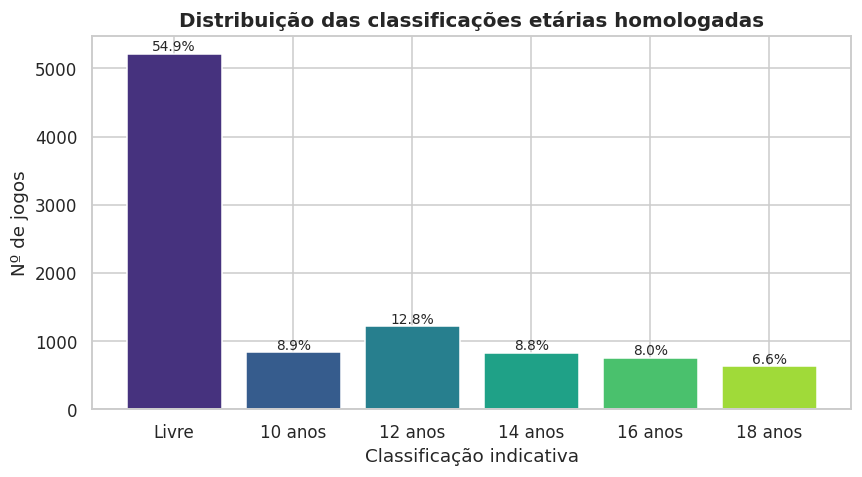

In [10]:
fig, ax = plt.subplots(figsize=(8,4.5))
vc = df["Atribuida_label"].value_counts().reindex(order_lbl)
pct = vc/vc.sum()*100
bars = ax.bar(order_lbl, vc.values, color=sns.color_palette("viridis",6))
for b,p in zip(bars,pct):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+40, f"{p:.1f}%", ha="center", fontsize=9)
ax.set_title("Distribuição das classificações etárias homologadas", fontweight="bold")
ax.set_xlabel("Classificação indicativa"); ax.set_ylabel("Nº de jogos")
plt.tight_layout(); plt.show()

**Interpretação.** A distribuição é fortemente assimétrica: **~55% dos jogos são "Livre"**.
As faixas restantes somam ~45%, com destaque para "12 anos" (~13%). As faixas mais
restritivas — "16" e "18" — são as menos frequentes (juntas, ~15%). Ou seja, o acervo
brasileiro de jogos classificados é majoritariamente de conteúdo adequado a todos os públicos.

### P1 — Diversidade e intensidade dos descritores ao longo do tempo

**Gráfico 2.** Média de descritores de conteúdo por jogo em cada período (proxy de *diversidade*).

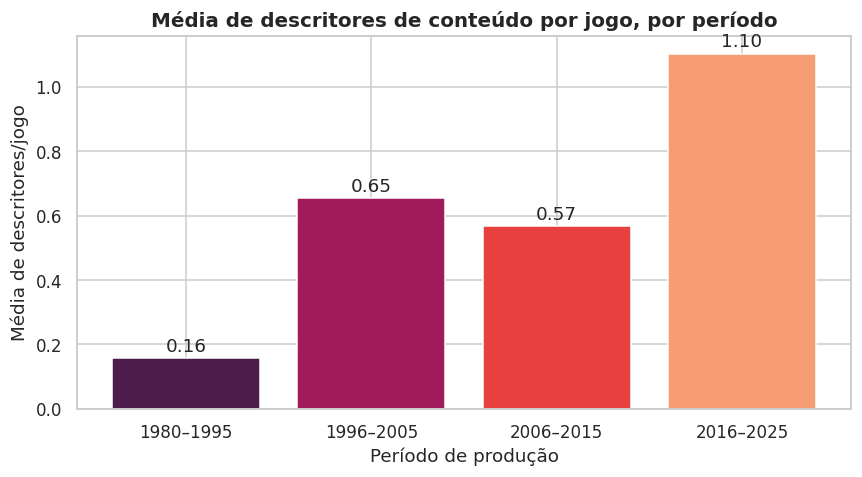

In [11]:
media = df_per.groupby("Periodo", observed=True)["n_descritores"].mean().reindex(order_per)
fig, ax = plt.subplots(figsize=(8,4.5))
bars = ax.bar(order_per, media.values, color=sns.color_palette("rocket",4))
for b in bars: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f"{b.get_height():.2f}", ha="center")
ax.set_title("Média de descritores de conteúdo por jogo, por período", fontweight="bold")
ax.set_xlabel("Período de produção"); ax.set_ylabel("Média de descritores/jogo")
plt.tight_layout(); plt.show()

**Interpretação.** A média de descritores por jogo **cresce ao longo do tempo**, saindo de
0,16 (1980–1995) para **1,10 no período 2016–2025** — quase o dobro do período anterior.
Isso indica que jogos mais recentes recebem, em média, **mais marcações de conteúdo sensível**.
*Ressalva:* o valor baixo de 1980–1995 também reflete registros antigos com menos detalhamento
("Sem informação"), então parte do salto é metodológica, não só de conteúdo.

**Gráfico 3.** Prevalência de cada tipo de conteúdo por período (proxy de *intensidade* por categoria).

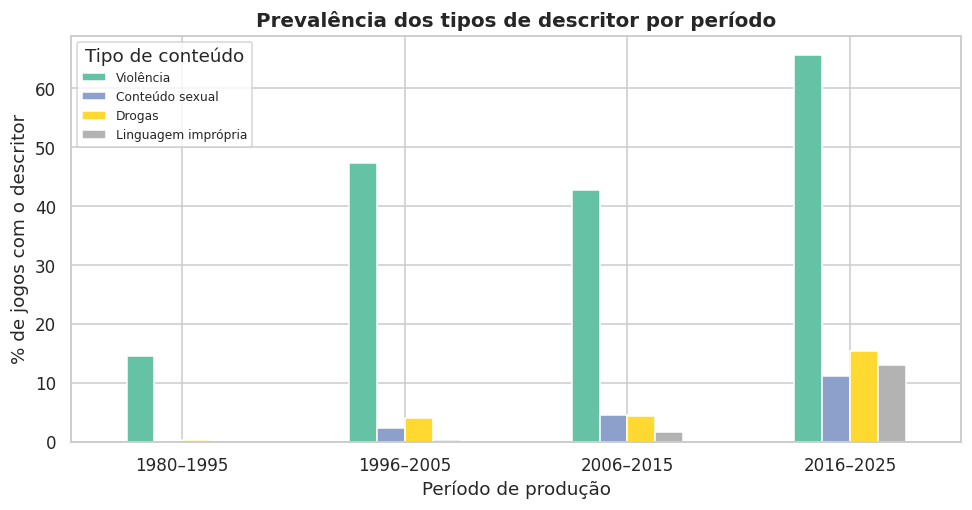

In [12]:
fams = ["cat_violencia","cat_sexual","cat_drogas","cat_linguagem"]
nice = {"cat_violencia":"Violência","cat_sexual":"Conteúdo sexual",
        "cat_drogas":"Drogas","cat_linguagem":"Linguagem imprópria"}
piv = (df_per.groupby("Periodo", observed=True)[fams].mean()*100).reindex(order_per)
fig, ax = plt.subplots(figsize=(9,4.8))
piv.rename(columns=nice).plot(kind="bar", ax=ax, colormap="Set2")
ax.set_title("Prevalência dos tipos de descritor por período", fontweight="bold")
ax.set_xlabel("Período de produção"); ax.set_ylabel("% de jogos com o descritor")
ax.legend(title="Tipo de conteúdo", fontsize=8)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**Interpretação.** A **violência** é, de longe, o descritor mais comum em todos os períodos,
chegando a **~66% dos jogos em 2016–2025**. Mas o crescimento mais marcante está nas demais
categorias: **conteúdo sexual, drogas e linguagem imprópria** eram quase inexistentes até 2015 e
saltam para 11%, 15% e 13% respectivamente no período mais recente. Ou seja, além de mais
frequente, o conteúdo sensível ficou **mais diverso** nos jogos recentes.

**Gráfico 4.** Quantos jogos, a cada ano, tinham **pelo menos um aviso de conteúdo sensível**
(o que chamamos de "descritor": violência, drogas, palavrão, conteúdo sexual etc.).

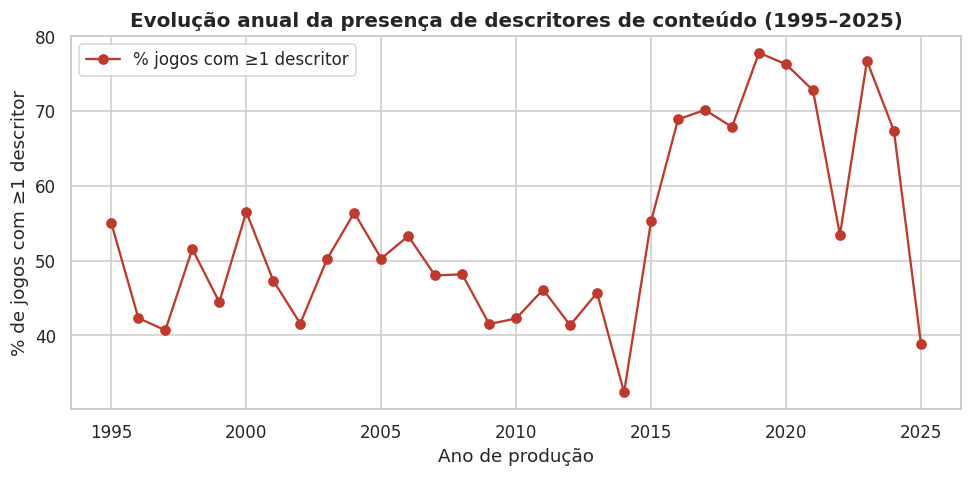

Força da relação entre o ano e o nº de avisos de conteúdo: 0.17
(0 = sem relação; 1 = relação perfeita. Aqui deu positivo, mas fraco.)


In [13]:
sub = df.dropna(subset=["Ano"])
sub = sub[sub["Ano"].between(1995,2025)]
yr = sub.groupby("Ano")["n_descritores"].apply(lambda s:(s>0).mean()*100)
fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(yr.index, yr.values, marker="o", color="#c0392b", label="% jogos com ≥1 descritor")
ax.set_title("Evolução anual da presença de descritores de conteúdo (1995–2025)", fontweight="bold")
ax.set_xlabel("Ano de produção"); ax.set_ylabel("% de jogos com ≥1 descritor")
ax.legend(); plt.tight_layout(); plt.show()

corr = sub["Ano"].corr(sub["n_descritores"])
print(f"Força da relação entre o ano e o nº de avisos de conteúdo: {corr:.2f}")
print("(0 = sem relação; 1 = relação perfeita. Aqui deu positivo, mas fraco.)")

**O que este gráfico mostra.** Cada ponto é um ano. A linha diz quantos jogos daquele ano (em %)
tinham **pelo menos um aviso de conteúdo sensível** — ou seja, jogos marcados com violência,
drogas, palavrão, conteúdo sexual etc. Jogos sem nada a sinalizar (os "Livre", limpos) ficam de fora dessa conta.

**O que dá pra concluir.** Até por volta de 2014, **mais ou menos metade dos jogos** (40% a 50%)
tinha algum aviso. **A partir de 2015 esse número sobe e fica perto de 70%**: hoje a maioria dos
jogos lançados tem algum conteúdo sensível, enquanto antes a divisão era mais equilibrada. Isso
reforça a resposta da nossa pergunta principal — **jogos mais novos costumam ter mais conteúdo
sensível do que os antigos**.

⚠️ O ponto de 2025 aparece baixo só porque o ano ainda está **incompleto** na base (poucos jogos
cadastrados até agora), e não porque o conteúdo diminuiu de verdade.

### P3 — Plataformas mais frequentes e sua evolução

**Gráfico 5.** As 12 plataformas que mais aparecem no acervo (cada jogo pode ter várias).

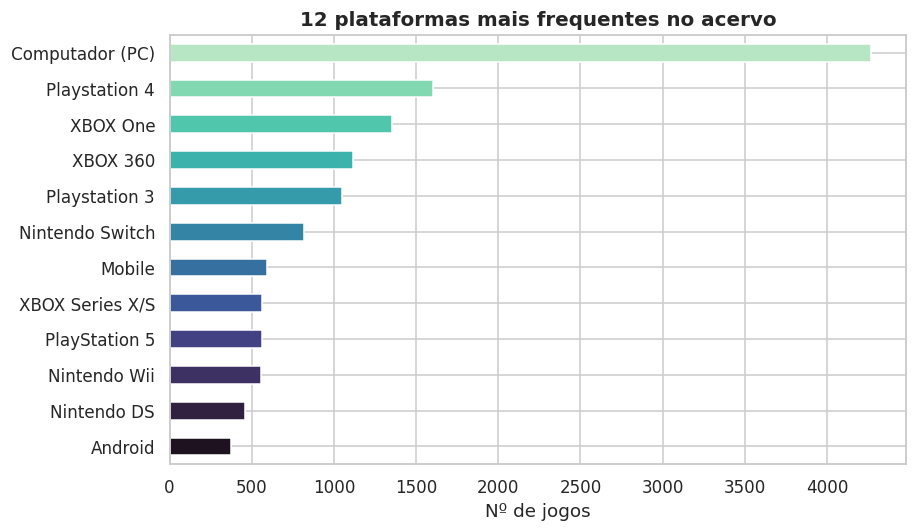

In [14]:
cnt = collections.Counter()
for l in df["plat_list"]:
    for p in l: cnt[p]+=1
top = pd.Series(dict(cnt)).sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(8.5,5))
top[::-1].plot(kind="barh", ax=ax, color=sns.color_palette("mako",12))
ax.set_title("12 plataformas mais frequentes no acervo", fontweight="bold")
ax.set_xlabel("Nº de jogos"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Interpretação.** O **Computador (PC)** é a plataforma mais frequente de longe (~4.300 jogos),
seguido pelos consoles atuais — **PlayStation 4, Xbox One, Xbox 360, PlayStation 3** e
**Nintendo Switch**. (Tiramos da análise a categoria "Outra plataforma", que aparecia bastante mas
não informa qual é o aparelho.) O PC lidera porque muitos jogos saem em várias plataformas ao
mesmo tempo e quase sempre incluem a versão de PC.

**Gráfico 6.** Penetração das famílias de plataforma em cada período (tendência).

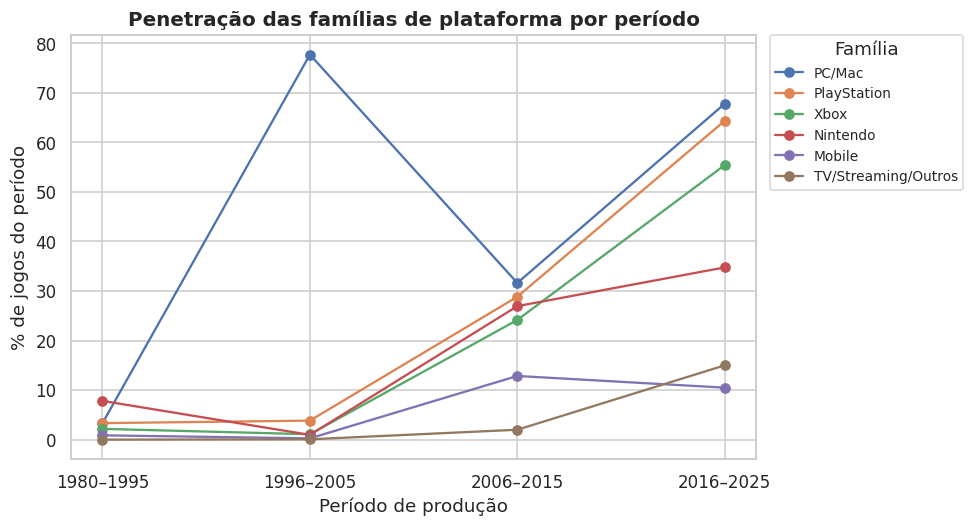

In [15]:
famcols = ["PC/Mac","PlayStation","Xbox","Nintendo","Mobile","TV/Streaming/Outros"]
rows = {}
for per, grp in df_per.groupby("Periodo", observed=True):
    rows[per] = {f: grp["fam_list"].apply(lambda l: f in l).mean()*100 for f in famcols}
fp = pd.DataFrame(rows).T.reindex(order_per)
fig, ax = plt.subplots(figsize=(9.5,5))
for f in famcols:
    ax.plot(order_per, fp[f], marker="o", label=f)
ax.set_title("Penetração das famílias de plataforma por período", fontweight="bold")
ax.set_xlabel("Período de produção"); ax.set_ylabel("% de jogos do período")
# legenda FORA do gráfico (lado direito), para não cobrir as linhas
ax.legend(title="Família", fontsize=9, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
fig.subplots_adjust(right=0.78)
plt.show()

**Interpretação.** A plataforma dominante **muda ao longo do tempo**:
- **1996–2005:** domínio quase total do **PC** (~78% dos jogos), com consoles ainda pouco representados na base.
- **2006–2015:** mercado se **diversifica** — PlayStation, Xbox e Nintendo passam a dividir espaço de forma equilibrada (~25–29% cada) e o **Mobile** surge.
- **2016–2025:** consolida-se o modelo **multiplataforma**: a maioria dos jogos sai simultaneamente em **PC (~68%), PlayStation (~64%) e Xbox (~55%)**.

*Ressalva:* o período 1980–1995 aparece baixo em todas as famílias porque a maioria dos jogos
antigos **não tinha a plataforma identificada** na base (vinham como "Outra plataforma", que
tiramos da análise).

### P4 — Concordância entre classificação pretendida e atribuída

**Gráfico 7.** Cada bolha é um cruzamento entre o que a empresa **pediu** (eixo X) e o que o órgão
**decidiu** (eixo Y). O **tamanho da bolha** mostra quantos jogos caíram naquele cruzamento. A linha
pontilhada é a "linha da concordância": bolhas **em cima dela** = concordaram; **abaixo** = órgão foi
mais flexível (liberou faixa menor); **acima** = órgão foi mais rígido (exigiu faixa maior).

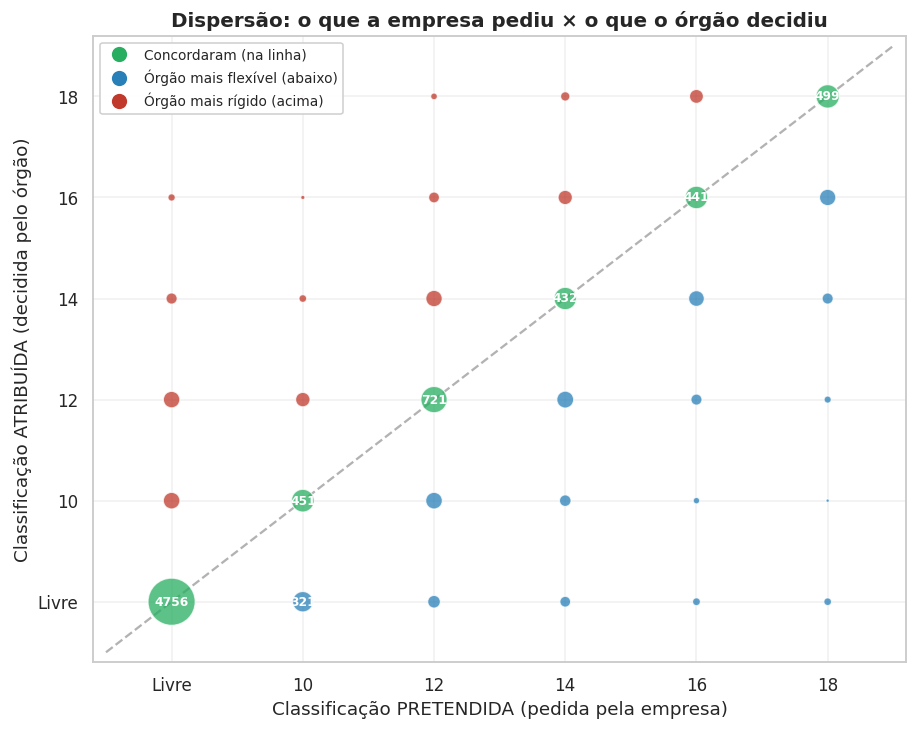

In [16]:
from matplotlib.lines import Line2D

# posições igualmente espaçadas (0..5) para as 6 faixas
pos = {0:0, 10:1, 12:2, 14:3, 16:4, 18:5}
labels7 = ["Livre","10","12","14","16","18"]

tmp = df.dropna(subset=["Pretendida_num","Atribuida_num"]).copy()
tmp["px"] = tmp["Pretendida_num"].map(pos)   # x = pedida
tmp["ay"] = tmp["Atribuida_num"].map(pos)    # y = decidida
agg = tmp.groupby(["px","ay"]).size().reset_index(name="n")

def cor(r):
    if r["ay"] == r["px"]: return "#27ae60"   # concordaram
    if r["ay"] <  r["px"]: return "#2980b9"   # órgão mais flexível
    return "#c0392b"                           # órgão mais rígido
agg["cor"] = agg.apply(cor, axis=1)

fig, ax = plt.subplots(figsize=(8.5,6.8))
ax.plot([-0.5,5.5],[-0.5,5.5], "--", color="gray", alpha=0.6, zorder=0)   # linha da concordância
ax.scatter(agg["px"], agg["ay"], s=(agg["n"]**0.62)*5, c=agg["cor"],
           alpha=0.75, edgecolors="white", linewidths=0.8, zorder=3)
# rótulo só nas bolhas grandes (para não poluir)
for _, r in agg.iterrows():
    if r["n"] >= 200:
        ax.text(r["px"], r["ay"], int(r["n"]), ha="center", va="center",
                fontsize=8, color="white", fontweight="bold", zorder=4)

ax.set_xticks(range(6)); ax.set_xticklabels(labels7)
ax.set_yticks(range(6)); ax.set_yticklabels(labels7)
ax.set_xlim(-0.6,5.6); ax.set_ylim(-0.6,5.6); ax.grid(True, alpha=0.3)
ax.set_xlabel("Classificação PRETENDIDA (pedida pela empresa)")
ax.set_ylabel("Classificação ATRIBUÍDA (decidida pelo órgão)")
ax.set_title("Dispersão: o que a empresa pediu × o que o órgão decidiu", fontweight="bold")
leg = [Line2D([0],[0], marker="o", color="w", markerfacecolor="#27ae60", markersize=11, label="Concordaram (na linha)"),
       Line2D([0],[0], marker="o", color="w", markerfacecolor="#2980b9", markersize=11, label="Órgão mais flexível (abaixo)"),
       Line2D([0],[0], marker="o", color="w", markerfacecolor="#c0392b", markersize=11, label="Órgão mais rígido (acima)")]
ax.legend(handles=leg, loc="upper left", fontsize=9, framealpha=0.95)
plt.tight_layout(); plt.show()

**O que dá pra concluir.** A maior parte das bolhas — e as maiores — está **em cima da linha**,
mostrando que empresa e órgão concordam na maioria dos casos (a maior de todas, com 4.756 jogos, é
"Livre × Livre"). Entre as bolhas que saem da linha, as **azuis (abaixo) são maiores e mais
frequentes que as vermelhas (acima)**. Em outras palavras: quando há discordância, o órgão costuma
**liberar uma faixa menor** do que a empresa pediu — ele tende a ser mais flexível do que rígido.

**Gráfico 8.** Percentual de concordância e, entre as divergências, a direção (mais rígido vs. mais flexível).

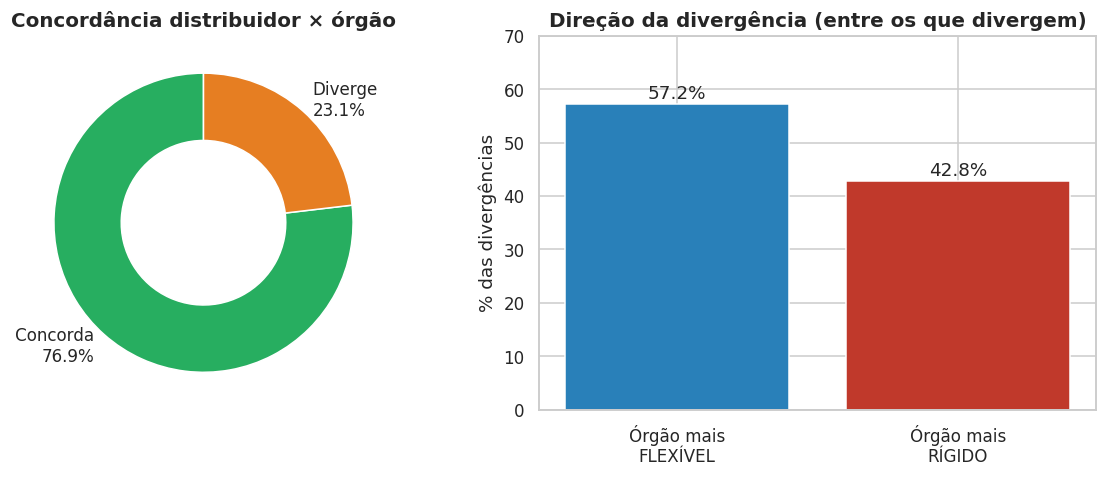

Concordância total: 76.87%
Divergências: 2196 jogos (23.13%)
  -> órgão mais FLEXÍVEL: 57.2%   |   órgão mais RÍGIDO: 42.8%
Diferença média (atribuída - pretendida) nas divergências: -0.59


In [17]:
df["concorda"] = df["Pretendida_num"] == df["Atribuida_num"]
conc = df["concorda"].mean()*100
div = df[~df["concorda"]]
flex = (div["Atribuida_num"] < div["Pretendida_num"]).mean()*100   # órgão liberou faixa menor
rig  = (div["Atribuida_num"] > div["Pretendida_num"]).mean()*100   # órgão exigiu faixa maior

fig, axes = plt.subplots(1,2, figsize=(11,4.5))
axes[0].pie([conc,100-conc], labels=[f"Concorda\n{conc:.1f}%", f"Diverge\n{100-conc:.1f}%"],
            colors=["#27ae60","#e67e22"], startangle=90, wedgeprops={"width":0.45})
axes[0].set_title("Concordância distribuidor × órgão", fontweight="bold")
b = axes[1].bar(["Órgão mais\nFLEXÍVEL","Órgão mais\nRÍGIDO"], [flex,rig], color=["#2980b9","#c0392b"])
for bar in b: axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f"{bar.get_height():.1f}%", ha="center")
axes[1].set_title("Direção da divergência (entre os que divergem)", fontweight="bold")
axes[1].set_ylabel("% das divergências"); axes[1].set_ylim(0,70)
plt.tight_layout(); plt.show()

print(f"Concordância total: {conc:.2f}%")
print(f"Divergências: {len(div)} jogos ({100-conc:.2f}%)")
print(f"  -> órgão mais FLEXÍVEL: {flex:.1f}%   |   órgão mais RÍGIDO: {rig:.1f}%")
print(f"Diferença média (atribuída - pretendida) nas divergências: {(div['Atribuida_num']-div['Pretendida_num']).mean():.2f}")

**Interpretação.** Distribuidores e órgão **concordam em ~76,9%** dos casos. Nos ~23% que
divergem, o resultado é **contraintuitivo**: o órgão tende a ser **mais flexível (57,2%)** do que
mais rígido (42,8%) — ou seja, as empresas costumam **superestimar** a faixa etária e o órgão
**rebaixa** a classificação com mais frequência do que a eleva. A diferença média negativa
confirma esse "alívio" médio na faixa.

## 6. Conclusões

A análise respondeu à **pergunta orientadora** e às **quatro perguntas derivadas (P1 a P4)**. Abaixo está a resposta de cada uma, com os gráficos que servem de evidência.

**Pergunta orientadora — Existe correlação entre o ano de produção e a diversidade/intensidade dos descritores de conteúdo?**
Sim, há uma correlação **positiva, porém fraca-moderada**. A média de descritores por jogo quase dobrou do penúltimo para o último período (0,57 → 1,10) e a proporção de jogos com algum descritor saltou de ~40% para ~70% depois de 2015. A correlação de Pearson (≈ 0,17 no período 1995–2025) confirma a tendência de alta, mas mostra que o ano não é o único fator que explica esse aumento.
*(Evidências: Gráficos 2, 3 e 4.)*

**P1 — A diversidade e a intensidade dos descritores mudam ao longo das décadas?**
Sim. Os jogos passaram a ter **mais** descritores com o tempo e o conteúdo ficou **mais diverso**: a violência sempre dominou, mas conteúdo sexual, drogas e linguagem imprópria (antes raros) passaram a aparecer em 11–15% dos jogos recentes.
*(Evidências: Gráficos 2, 3 e 4.)*

**P2 — Como se distribuem as classificações etárias?**
O acervo é majoritariamente **"Livre"**: cerca de 55% dos jogos têm essa faixa e apenas ~15% são "16/18". A distribuição é, portanto, fortemente concentrada nas faixas mais baixas.
*(Evidência: Gráfico 1.)*

**P3 — Quais plataformas são mais frequentes e como mudam ao longo do tempo?**
O **Computador (PC)** é a plataforma mais frequente de longe (~4.300 jogos). E a plataforma dominante muda com o tempo: o PC liderava em 1996–2005 (~78%), o mercado se diversificou entre consoles em 2006–2015 e, em 2016–2025, consolidou-se o **lançamento simultâneo** em PC, PlayStation e Xbox.
*(Evidências: Gráficos 5 e 6.)*

**P4 — Qual a concordância entre a classificação pretendida e a atribuída? Nas divergências, o órgão é mais rígido ou mais flexível?**
Distribuidores e órgão **concordam em ~76,9%** dos pedidos (a faixa pretendida foi homologada sem mudança). Entre os ~23% de divergências, o órgão **reduziu** a faixa etária com mais frequência (57,2%) do que aumentou (42,8%). Ou seja, quando há divergência o órgão tende a ser **mais flexível**, enquanto as empresas tendem a ser mais conservadoras (pedir uma faixa mais alta do que a necessária).
*(Evidências: Gráficos 7 e 8.)*

**Síntese.** O conteúdo dos jogos cresceu em quantidade e variedade ao longo dos anos (orientadora e P1), o acervo é predominantemente "Livre" (P2), a distribuição migrou de PC para multiplataforma (P3) e há alta concordância entre empresas e regulador, com o órgão sendo mais flexível nas exceções (P4).

## Limitações
- O campo **"Sem informação"** (em ano, descritores e plataformas) pode subestimar conteúdos de jogos antigos; parte do crescimento dos descritores pode ser melhoria de registro, e não só aumento real de conteúdo.
- O **ano de 2025 está incompleto**, então não deve ser lido como uma queda real.
- A base tem registros desde 1980 (não só 1995). Como tiramos a categoria **"Outra plataforma"** (que não diz qual é o aparelho), os jogos antigos (quase todos sem plataforma identificada) quase não aparecem nos gráficos de plataforma.
- Descritores e plataformas são **multivalorados**: um mesmo jogo pode ter vários, então os percentuais por categoria somam mais de 100%.
